# Teste — módulo de coleta

**Kernel:** conda `moradinha`  
**Diretório de trabalho:** deve ser `e:/Doutorado/UFABC/moradinha/` (raiz do projeto)

In [2]:
import logging
import sys
from pathlib import Path

# Detecta a raiz do projeto subindo a partir do cwd até encontrar modulo_coleta/
def _encontrar_raiz() -> Path:
    candidato = Path.cwd()
    for _ in range(6):
        if (candidato / "modulo_coleta").is_dir():
            return candidato
        candidato = candidato.parent
    raise FileNotFoundError(
        f"Raiz do projeto não encontrada a partir de '{Path.cwd()}'. "
        "Execute o notebook com o cwd dentro da pasta do projeto."
    )

ROOT = _encontrar_raiz()
print(f"ROOT detectado: {ROOT}")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Logging legível no notebook
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,
)

print("OK")

ROOT detectado: c:\Users\julio.santos03\Documents\moradinha-master
OK


In [3]:
from modulo_coleta.orquestrador import coletar_municipio

11:49:20 [INFO] Dependências ausentes: pyarrow. Instalando via pip...
11:50:15 [INFO] Instalados com sucesso: pyarrow


## Parâmetros

Edite o código IBGE e os grupos desejados antes de rodar.

In [4]:
CODIGO_IBGE   = "2701407"          # Campo Alegre-AL (usado nos testes anteriores)
NOME_PASTA    = "al_campo_alegre"  # None = derivado automaticamente via geobr
GRUPOS        = [1, 2, 3, 4, 5]   # remova grupos que não quer coletar
BASE_DIR      = ROOT / "data"
FORCAR        = False              # True = reprocessa mesmo que arquivos já existam

In [5]:
resultados = coletar_municipio(
    codigo_ibge=CODIGO_IBGE,
    grupos=GRUPOS,
    base_dir=BASE_DIR,
    nome_municipio=NOME_PASTA,
    forcar=FORCAR,
)

11:50:26 [INFO] Município: al_campo_alegre (IBGE: 2701407)
11:50:27 [INFO] DuckDB aberto: c:\Users\julio.santos03\Documents\moradinha-master\data\processed\al_campo_alegre\al_campo_alegre.duckdb
11:50:27 [INFO] ============================================================
11:50:27 [INFO] Iniciando grupo1_geometrias...
11:50:27 [INFO] [Grupo 1] Limite municipal
11:50:27 [INFO] Baixando limite municipal via geobr (codigo_ibge=2701407)
11:50:30 [INFO] Created 1 records


c:\Users\julio.santos03\Documents\moradinha-master\modulo_coleta\utils\db_utils.py:140: UserWarning: Geometry column does not contain geometry.
  df_para_salvar["geometry"] = gdf.geometry.apply(lambda geom: geom.wkb)


11:50:30 [INFO] Tabela 'limite_municipal' salva: 1 registros.
11:50:30 [INFO] [Grupo 1] Limite municipal OK
11:50:30 [INFO] [Grupo 1] Setores censitarios
11:50:30 [INFO] Baixando: https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_de_setores_censitarios__divisoes_intramunicipais/censo_2022_preliminar/setores/gpkg/UF/AL/AL_Malha_Preliminar_2022.gpkg → c:\Users\julio.santos03\Documents\moradinha-master\data\raw\al_campo_alegre\geometria\AL_Malha_Preliminar_2022.gpkg


AL_Malha_Preliminar_2022.gpkg: 100%|██████████| 24.7M/24.7M [00:39<00:00, 653kB/s] 

11:51:10 [INFO] Download concluído: c:\Users\julio.santos03\Documents\moradinha-master\data\raw\al_campo_alegre\geometria\AL_Malha_Preliminar_2022.gpkg (MD5: e211c0d117de866545fde78b98ee322b)


...

11:54:18 [INFO] 510 arquivo(s) extraído(s) em c:\Users\julio.santos03\Documents\moradinha-master\data\raw\al_campo_alegre\logradouros\_faces_al
11:54:18 [INFO] Faces de logradouro: 1682 faces carregadas
11:54:18 [INFO] Created 1,682 records
11:54:18 [INFO] Tabela 'faces_logradouro' salva: 1682 registros.
11:54:18 [INFO] [Grupo 3] Faces OK: 1682 faces
11:54:18 [INFO] [Grupo 3] Eixos OSM


c:\Users\julio.santos03\Documents\moradinha-master\modulo_coleta\utils\db_utils.py:140: UserWarning: Geometry column does not contain geometry.
  df_para_salvar["geometry"] = gdf.geometry.apply(lambda geom: geom.wkb)


11:54:22 [INFO] Baixando eixos OSM (network_type=all)...
11:54:33 [INFO] Eixos OSM baixados: 3294 arestas
11:54:33 [INFO] Created 3,294 records
11:54:33 [INFO] Tabela 'eixos_osm' salva: 3294 registros.
11:54:33 [INFO] [Grupo 3] Eixos OSM OK: 3294 arestas
11:54:33 [INFO] Grupo 3 finalizado — status: ok
11:54:33 [INFO] ============================================================
11:54:33 [INFO] Iniciando grupo4_luminosidade...
11:54:33 [ERROR] Tile VIIRS average_masked não encontrado em 'c:\Users\julio.santos03\Documents\moradinha-master\data\raw\tiles_globais'. Baixe em: https://eogdata.mines.edu/nighttime_light/annual/v22/ (registro gratuito, licença CC BY 4.0) e salve nessa pasta.
11:54:33 [INFO] Grupo 4 finalizado — status: pulado
11:54:33 [INFO] ============================================================
11:54:33 [INFO] Iniciando grupo5_pnadc...
11:54:33 [ERROR] [Grupo 5] Erro: Rscript não encontrado no PATH nem em C:/Program Files/R/.
Para corrigir:
  1. Instale o R: https://cran.

c:\Users\julio.santos03\Documents\moradinha-master\modulo_coleta\utils\db_utils.py:140: UserWarning: Geometry column does not contain geometry.
  df_para_salvar["geometry"] = gdf.geometry.apply(lambda geom: geom.wkb)


11:54:33 [INFO] Tabela 'setores_censitarios' lida do DuckDB: 66 feições.
11:54:33 [INFO] Tabela 'grade_estatistica' lida do DuckDB: 976 feições.
11:54:34 [INFO] Tabela 'areas_ponderacao' lida do DuckDB: 2 feições.
11:54:34 [INFO] Tabela 'faces_logradouro' lida do DuckDB: 1682 feições.
11:54:34 [INFO] Tabela 'eixos_osm' lida do DuckDB: 3294 feições.
11:54:34 [INFO] Tabela 'enderecos_cnefe' lida do DuckDB: 14966 feições.
11:54:35 [INFO] Tabela 'limite_municipal' lida do DuckDB: 1 feições.
11:54:35 [INFO] Mapa salvo em: c:\Users\julio.santos03\Documents\moradinha-master\data\processed\al_campo_alegre\mapa_coleta.png
11:54:36 [INFO] ============================================================
11:54:36 [INFO] Coleta concluída para al_campo_alegre
11:54:36 [INFO]   Grupo 1: ok | camadas: ['limite_municipal', 'setores_censitarios', 'grade_estatistica', 'areas_ponderacao']
11:54:36 [INFO]   Grupo 2: ok | camadas: ['censo_domicilio01', 'censo_domicilio02', 'censo_responsavel01']
11:54:36 [INFO]

## Resumo dos resultados

In [6]:
from modulo_coleta.orquestrador import GRUPOS_DISPONIVEIS

for grupo, res in resultados.items():
    if grupo == "mapa":
        continue
    nome  = GRUPOS_DISPONIVEIS.get(grupo, f"grupo{grupo}")
    status = res.get("status", "?")
    camadas = res.get("camadas", [])
    msg    = res.get("mensagem", "")
    icone  = "✅" if status == "ok" else ("⏭️" if status == "pulado" else "❌")
    print(f"{icone} Grupo {grupo} ({nome}): {status}")
    if camadas:
        print(f"   camadas: {camadas}")
    if status != "ok":
        print(f"   msg: {msg}")

✅ Grupo 1 (grupo1_geometrias): ok
   camadas: ['limite_municipal', 'setores_censitarios', 'grade_estatistica', 'areas_ponderacao']
✅ Grupo 2 (grupo2_censo): ok
   camadas: ['censo_domicilio01', 'censo_domicilio02', 'censo_responsavel01']
✅ Grupo 3 (grupo3_logradouros): ok
   camadas: ['enderecos_cnefe', 'faces_logradouro', 'eixos_osm']
⏭️ Grupo 4 (grupo4_luminosidade): pulado
   msg: Tile VIIRS average_masked não encontrado em 'c:\Users\julio.santos03\Documents\moradinha-master\data\raw\tiles_globais'. Baixe em: https://eogdata.mines.edu/nighttime_light/annual/v22/ (registro gratuito, licença CC BY 4.0) e salve nessa pasta.
❌ Grupo 5 (grupo5_pnadc): erro
   msg: Rscript não encontrado no PATH nem em C:/Program Files/R/.
Para corrigir:
  1. Instale o R: https://cran.r-project.org/
  2. Durante a instalação, marque 'Add R to PATH'
  3. Reinicie o terminal/VS Code para atualizar o PATH
  4. Teste: abra o terminal e digite 'Rscript --version'


## Mapa de coleta

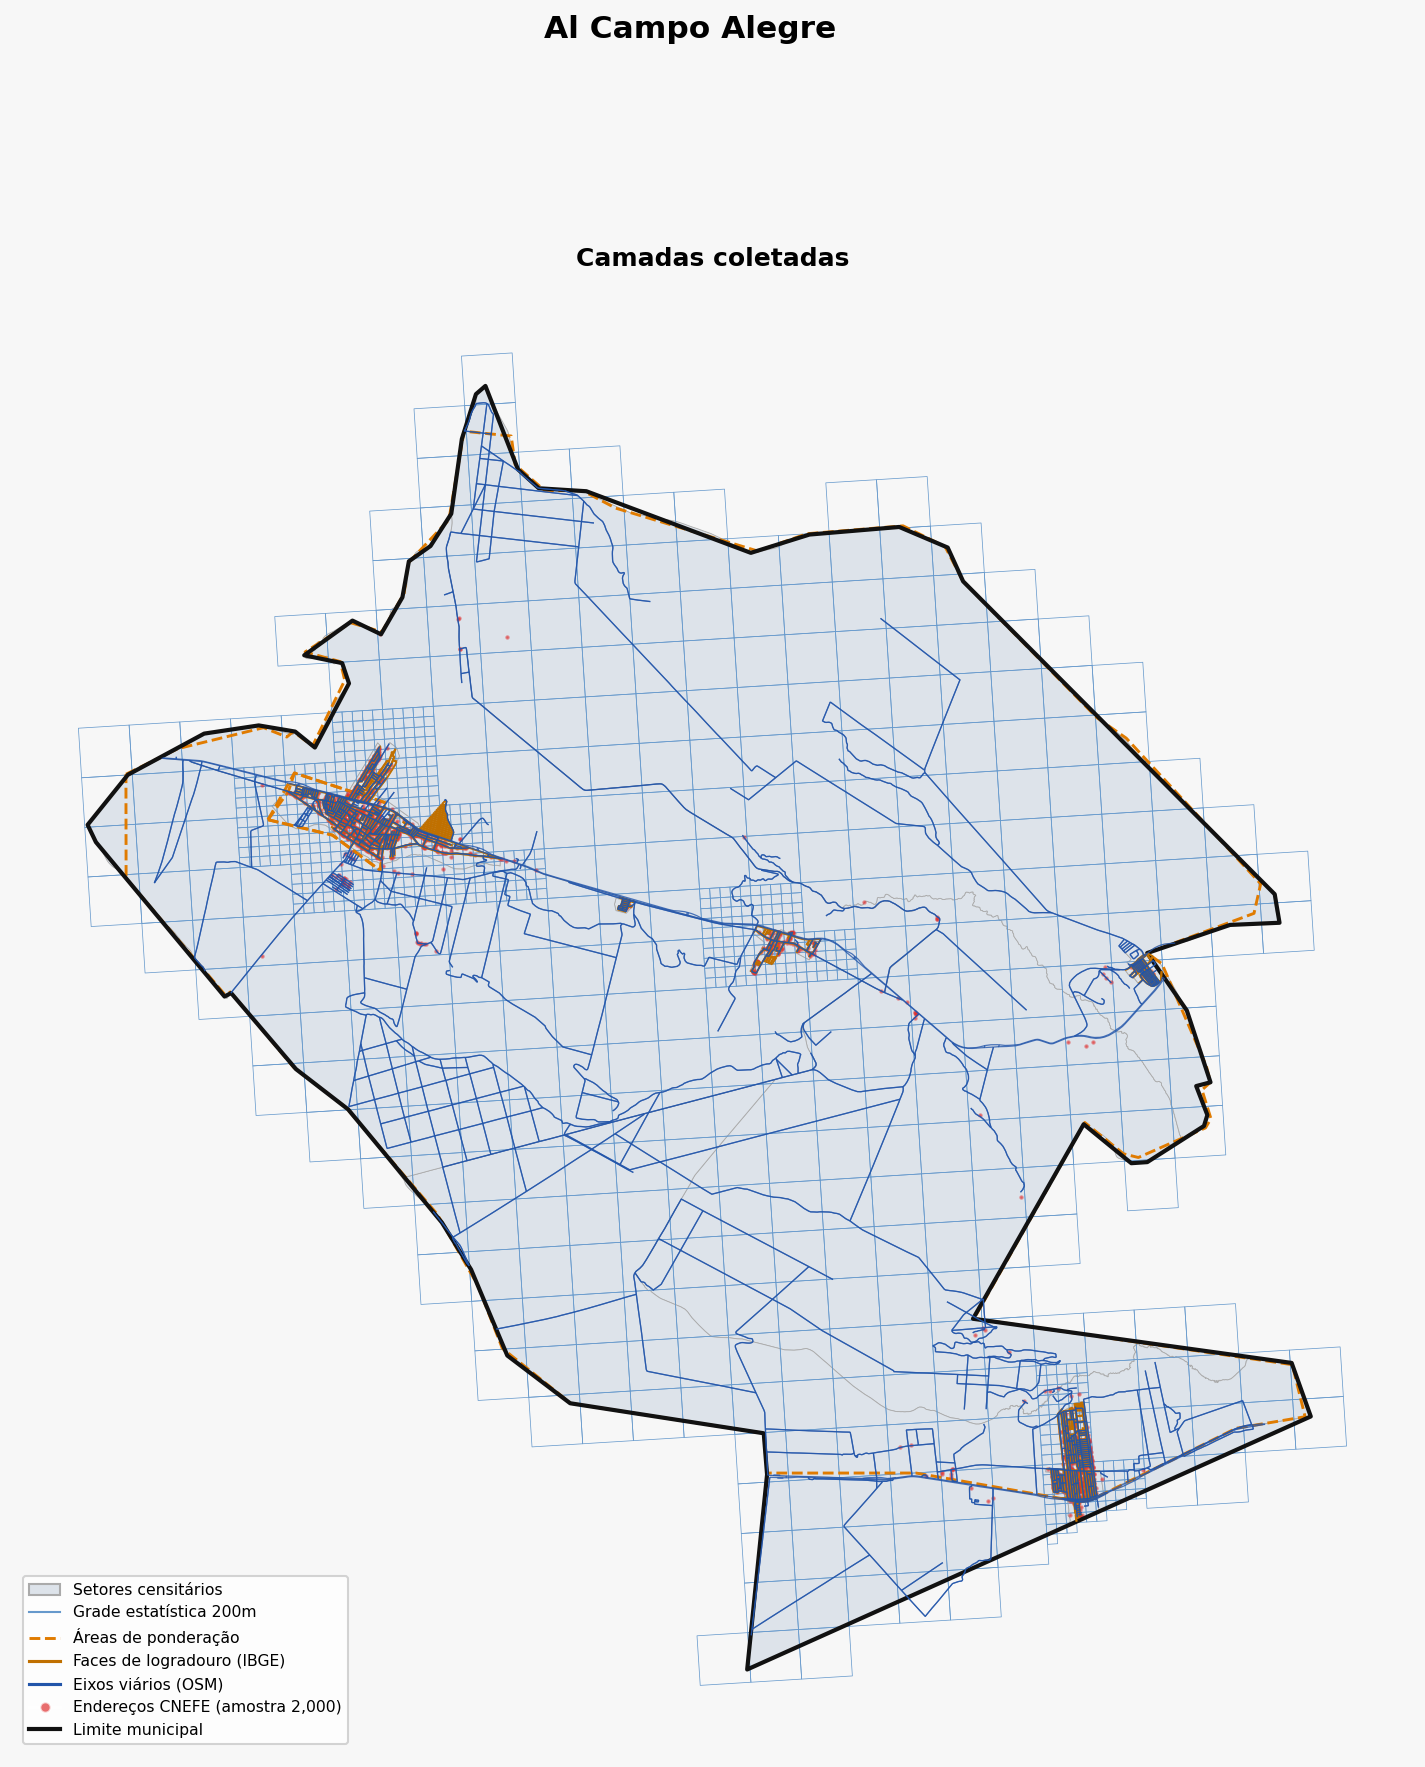

In [7]:
from IPython.display import Image, display

mapa_path = resultados.get("mapa")
if mapa_path and Path(mapa_path).exists():
    display(Image(filename=mapa_path, width=800))
else:
    print("Mapa não gerado.")

## Inspecionar o DuckDB

Célula opcional para checar as tabelas geradas.

In [ ]:
from modulo_coleta.utils.db_utils import abrir_conexao, listar_tabelas

db_path = BASE_DIR / "processed" / NOME_PASTA / f"{NOME_PASTA}.duckdb"
conn = abrir_conexao(db_path)
tabelas = listar_tabelas(conn)
print(f"Tabelas no banco ({NOME_PASTA}):")
for t in tabelas:
    n = conn.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"  {t}: {n} registros")
conn.close()